In [113]:
# Building various models to prict bmw car prices using the features from a dataset after cleaning the data ,EDA and preprocessing it for models

In [114]:
#importing necesssary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,KFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input,Dropout
import joblib

In [115]:
#loading the data
df=pd.read_csv(r"C:\Users\dell\OneDrive\Desktop\data\bmw.csv")
print(df)
df1=df.copy()

           model  year  price transmission  mileage fuelType  tax   mpg  \
0       5 Series  2014  11200    Automatic    67068   Diesel  125  57.6   
1       6 Series  2018  27000    Automatic    14827   Petrol  145  42.8   
2       5 Series  2016  16000    Automatic    62794   Diesel  160  51.4   
3       1 Series  2017  12750    Automatic    26676   Diesel  145  72.4   
4       7 Series  2014  14500    Automatic    39554   Diesel  160  50.4   
...          ...   ...    ...          ...      ...      ...  ...   ...   
10776         X3  2016  19000    Automatic    40818   Diesel  150  54.3   
10777   5 Series  2016  14600    Automatic    42947   Diesel  125  60.1   
10778   3 Series  2017  13100       Manual    25468   Petrol  200  42.8   
10779   1 Series  2014   9930    Automatic    45000   Diesel   30  64.2   
10780         X1  2017  15981    Automatic    59432   Diesel  125  57.6   

       engineSize  
0             2.0  
1             2.0  
2             3.0  
3             1.5  

exploratory data analysis

In [117]:
#getting all model names
print("total models: ",len(df["model"].unique()))
#there are 24 unique models
print("all models are: ")
print((df["model"].unique()))

total models:  24
all models are: 
[' 5 Series' ' 6 Series' ' 1 Series' ' 7 Series' ' 2 Series' ' 4 Series'
 ' X3' ' 3 Series' ' X5' ' X4' ' i3' ' X1' ' M4' ' X2' ' X6' ' 8 Series'
 ' Z4' ' X7' ' M5' ' i8' ' M2' ' M3' ' M6' ' Z3']


In [118]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [119]:
#geeting all null values 
df.isna().sum()
#there are no null values

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [121]:
#correlation of price with other variables
x=df.select_dtypes(exclude="object")
corr_matrix=x.corr()
print("correlation of price with other variables: ")
print(corr_matrix["price"].sort_values())

correlation of price with other variables: 
mileage      -0.605397
mpg          -0.204882
tax           0.263484
engineSize    0.460196
year          0.623756
price         1.000000
Name: price, dtype: float64


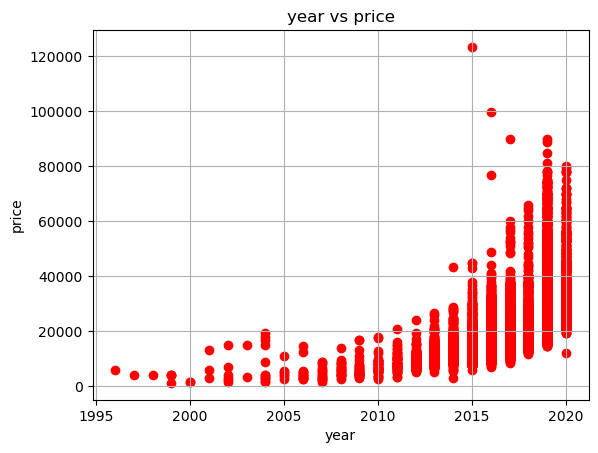

In [122]:
#scatter plot of price and year
#year has the positive relationship wtih price of the cars
plt.scatter(df["year"],df["price"],c="r")
plt.grid()
plt.title("year vs price")
plt.xlabel("year")
plt.ylabel("price")
plt.show()

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'mileage'}>,
        <Axes: title={'center': 'tax'}>],
       [<Axes: title={'center': 'mpg'}>,
        <Axes: title={'center': 'engineSize'}>]], dtype=object)

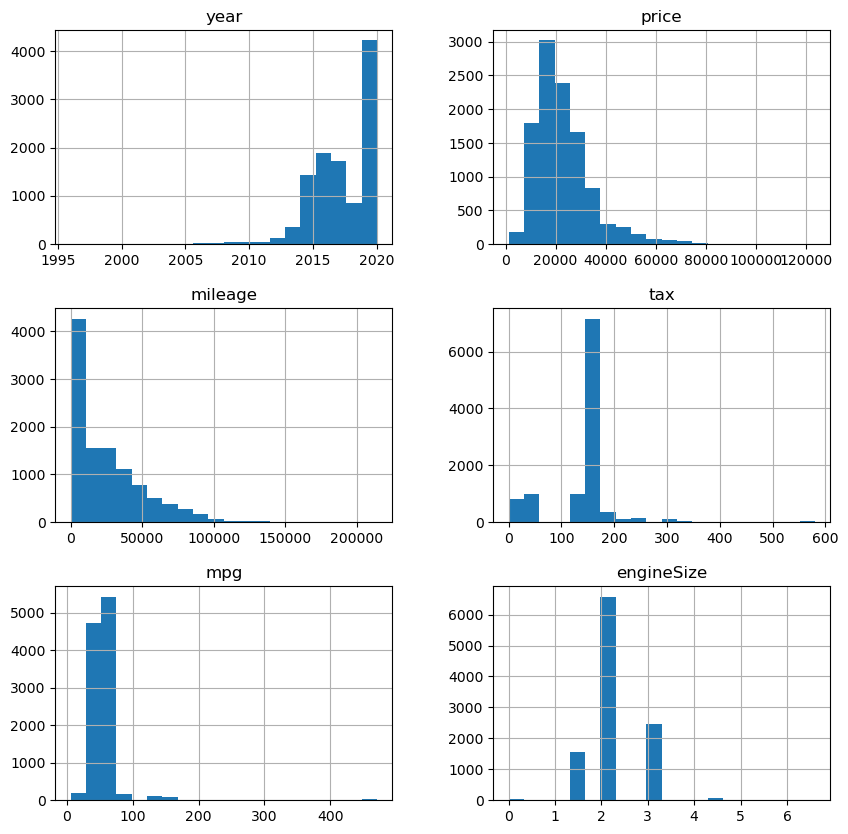

In [123]:
#histograms of different numerical variables
df.hist(bins=20,figsize=(10,10))

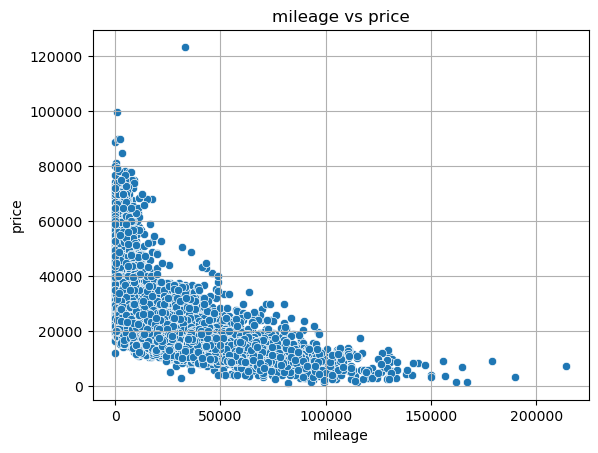

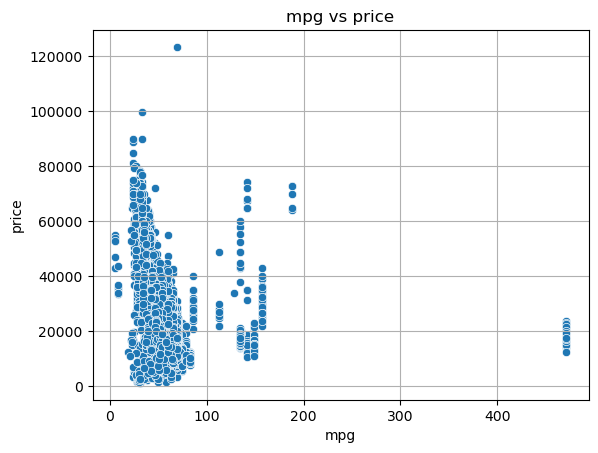

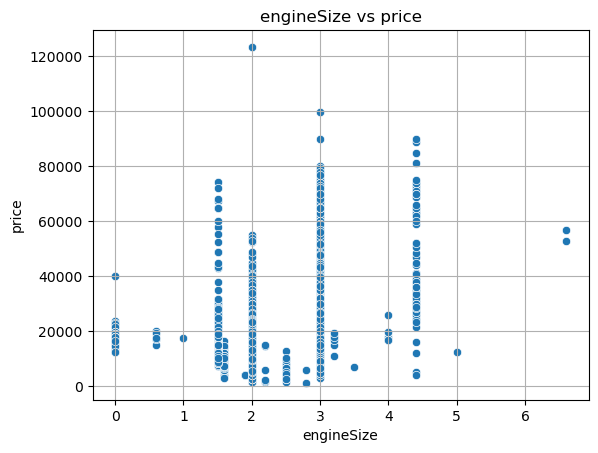

In [124]:
#main features plots against price
#mileage has negative relatioship with price 
#msot of the cars from low to high prices has mpg between 0 and 100
num_features=["mileage","mpg","engineSize"]
for col in num_features:
    sns.scatterplot(x=df[col],y=df["price"])
    plt.title(f"{col} vs price")
    plt.grid()
    plt.show()

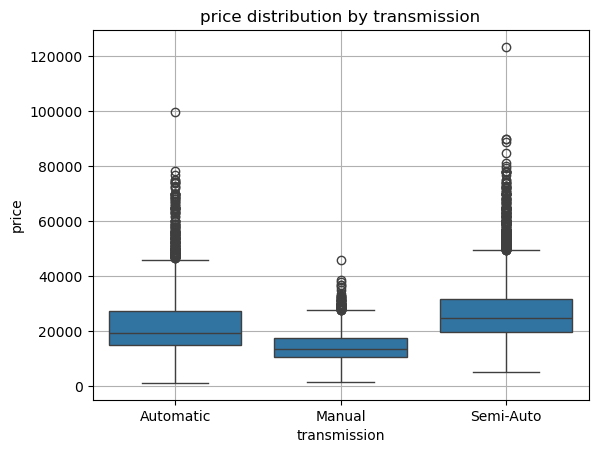

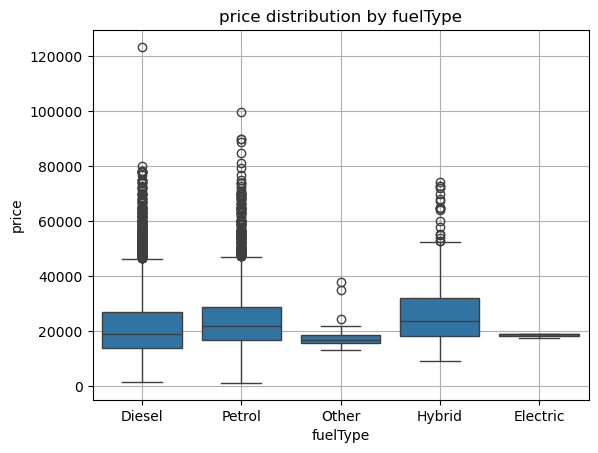

In [125]:
cat_features=["transmission","fuelType"]
for col in cat_features:
    sns.boxplot(x=df[col],y=df["price"])
    plt.title(f"price distribution by {col}")
    plt.grid()
    plt.show()

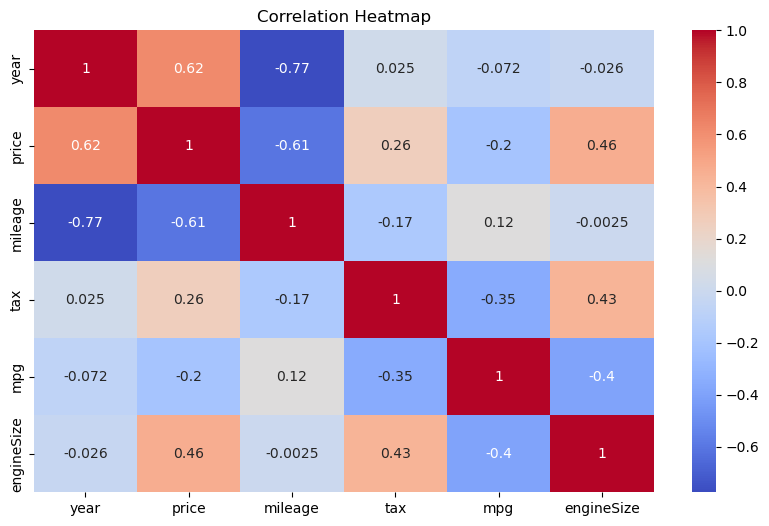

In [126]:
#the year feature has most positive relationship with price column
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

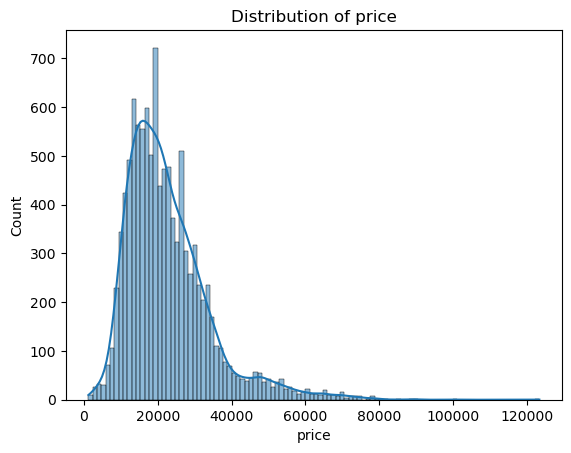

In [127]:
#the price is not equally spread it is right skewed
sns.histplot(df["price"],kde=True)
plt.title("Distribution of price")
plt.savefig("price_distribution.png",dpi=300,bbox_inches="tight")
plt.show()

In [128]:
#OneHotEncoding the categorical columns for the models to train 
ohc=OneHotEncoder(sparse_output=False)
x_modi=ohc.fit_transform(df[["model","transmission","fuelType"]])
x_modi1=pd.DataFrame(x_modi,columns=ohc.get_feature_names_out(["model","transmission","fuelType"]))
df_encoded=pd.concat([df.drop(["model","transmission","fuelType"],axis="columns"),x_modi1],axis=1)
print(df_encoded)

       year  price  mileage  tax   mpg  engineSize  model_ 1 Series  \
0      2014  11200    67068  125  57.6         2.0              0.0   
1      2018  27000    14827  145  42.8         2.0              0.0   
2      2016  16000    62794  160  51.4         3.0              0.0   
3      2017  12750    26676  145  72.4         1.5              1.0   
4      2014  14500    39554  160  50.4         3.0              0.0   
...     ...    ...      ...  ...   ...         ...              ...   
10776  2016  19000    40818  150  54.3         2.0              0.0   
10777  2016  14600    42947  125  60.1         2.0              0.0   
10778  2017  13100    25468  200  42.8         2.0              0.0   
10779  2014   9930    45000   30  64.2         2.0              1.0   
10780  2017  15981    59432  125  57.6         2.0              0.0   

       model_ 2 Series  model_ 3 Series  model_ 4 Series  ...  model_ i3  \
0                  0.0              0.0              0.0  ...        0.

In [129]:
#splitted the dataset for model
x1=df_encoded.drop("price",axis=1)
y1=df_encoded["price"]
x_train_1,x_test_1,y_train_1,y_test_1=train_test_split(x1,y1,train_size=0.8,random_state=42)
print(x_train_1)

      year  mileage  tax    mpg  engineSize  model_ 1 Series  model_ 2 Series  \
3652  2019     9165  145   50.4         2.0              0.0              0.0   
7007  2019     6650  145   37.7         3.0              0.0              0.0   
9045  2016    64231  145   53.3         3.0              0.0              0.0   
3910  2019     2799  135  141.2         1.5              0.0              0.0   
3635  2013    63583  200   45.6         3.0              0.0              0.0   
...    ...      ...  ...    ...         ...              ...              ...   
5734  2018    40456  145   64.2         2.0              0.0              0.0   
5191  2016    23210  200   39.8         3.0              1.0              0.0   
5390  2019     5652  145   47.9         2.0              0.0              0.0   
860   2016    14542  125   60.1         2.0              0.0              0.0   
7270  2016    17237  125   54.3         1.5              1.0              0.0   

      model_ 3 Series  mode

In [130]:
#building and training decision tree model
tree=DecisionTreeRegressor(max_depth=6,random_state=42)
tree.fit(x_train_1,y_train_1)
print("r2 score of tree model : ",tree.score(x_test_1,y_test_1))

r2 score of tree model :  0.8709518257387984


In [131]:
label_encoders={}
cat_cols=["model","transmission","fuelType"]
for col in cat_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    label_encoders[col]=le
x=df.drop("price",axis="columns")
y=df["price"]
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)
tree.fit(x_train,y_train)
print("r2 score of tree with label encoder: ",tree.score(x_test,y_test))

r2 score of tree with label encoder:  0.8858045735447412


In [132]:
#performing cross validatiion using tree model with KFold
kf=KFold(n_splits=5,shuffle=True,random_state=42)
cvs=cross_val_score(tree,x_train,y_train,cv=kf,scoring="r2")
print("cross val scores: ",cvs.mean())

cross val scores:  0.8869603779141675


In [133]:
# tuning the decision tree model for better predicitions
params={
    "max_depth":[4,6,8,20],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,5,10]
}
grid=GridSearchCV(tree,params,cv=5,scoring="r2")
grid.fit(x_train_1,y_train_1)
print(grid.best_params_,grid.best_score_)

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10} 0.9262867252745333


In [134]:
# training a random forest model
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train,y_train)
print("r2 score of random forest model: ",rf.score(x_test,y_test))

r2 score of random forest model:  0.9444480738037878


In [135]:
# preparing data for a neural network
num_cols=["mileage","mpg","engineSize","tax","year"]
cate_cols=['transmission','fuelType','model']
x1=df1.drop("price",axis=1)
y1=df1["price"]
xt,xtt,yt,ytt=train_test_split(x1,y1,train_size=0.8,random_state=42)
preprocessor=ColumnTransformer([
    ("num",StandardScaler(),num_cols),
    ("cat",OneHotEncoder(),cate_cols)
])
x_train_prep=preprocessor.fit_transform(xt)
x_test_prep=preprocessor.transform(xtt)
print("input shape for neural net: ",x_train_prep.shape)

input shape for neural net:  (8624, 37)


In [136]:
# building a neural network to check how it performs
model=Sequential([
    Dense(128,activation="relu",input_shape=(x_train_prep.shape[1],)),
    Dropout(0.1),
    Dense(100,activation="relu"),
    Dense(64,activation="relu"),
    Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
model.fit(x_train_prep,yt,epochs=30,batch_size=32,validation_split=0.2,verbose=0)
y_predicted=model.predict(x_test_prep)
def evaluate_metrics(y_test,y_predicted):
    return {"mse":mean_absolute_error(y_test,y_predicted),
           "rmse":np.sqrt(mean_squared_error(y_test,y_predicted)),
           "r2_score":r2_score(y_test,y_predicted)}
print(evaluate_metrics(y_test,y_predicted))

C:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
{'mse': 1928.4074730800157, 'rmse': 3252.9886947734494, 'r2_score': 0.9181693196296692}


In [137]:
Models={"linear_model":LinearRegression(),"tree_model":grid,"forest_model":rf}
for name, model in Models.items():
    model.fit(x_train_1,y_train_1)
    mae=-cross_val_score(model,x_train_1,y_train_1,cv=kf,scoring="neg_mean_absolute_error")
    print(f"mean absolute error of {name} is: ",mae.mean())
    rmse=-cross_val_score(model,x_train_1,y_train_1,cv=kf,scoring="neg_root_mean_squared_error")
    print(f"root mean square error of {name} is: ",rmse.mean())

mean absolute error of linear_model is:  2773.0695441919306
root mean square error of linear_model is:  4154.470400449565
mean absolute error of tree_model is:  1846.3541069602347
root mean square error of tree_model is:  3147.2475959475305
mean absolute error of forest_model is:  1540.3944626828415
root mean square error of forest_model is:  2624.3883830778263


In [138]:
# conclusion : RandomForest Model outperforms both decision tree and neural network with r2 score of 94.44%

In [139]:
final_model=rf
fm_predictions=final_model.predict(x_test_1)
def metrics_score(y_test,fm_predictions):
    return {"mae":mean_absolute_error(y_test,fm_predictions),
           "rmse":np.sqrt(mean_squared_error(y_test,fm_predictions)),
           "r2_score":r2_score(y_test,fm_predictions)}
print(evaluate_metrics(y_test,fm_predictions))

{'mse': 1611.0771275431496, 'rmse': 2751.569077169539, 'r2_score': 0.9414520192556358}


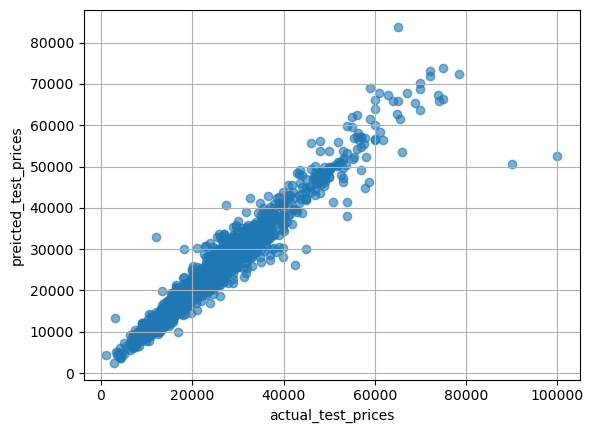

In [140]:
plt.scatter(y_test,fm_predictions,alpha=0.6)
plt.xlabel("actual_test_prices")
plt.ylabel("preicted_test_prices")
plt.grid()
plt.savefig("actual_vs_predicted.png",dpi=300,bbox_inches="tight")
plt.show()

In [174]:
joblib.dump(final_model,"bmw_price_predictor.pkl")

['bmw_price_predictor.pkl']